<a href="https://colab.research.google.com/github/mahathirumalathi97-web/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_excel("/content/Book1.xlsx")

In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
1,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
2,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
3,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices
4,6467-CHFZW,1,United States,California,Los Angeles,90028,"34.099869, -118.326843",34.099869,-118.326843,Male,...,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,1,77,5789,Competitor had better devices


In [ ]:
df.shape

(2128, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2128 entries, 0 to 2127
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         2128 non-null   object 
 1   Count              2128 non-null   int64  
 2   Country            2128 non-null   object 
 3   State              2128 non-null   object 
 4   City               2128 non-null   object 
 5   Zip Code           2128 non-null   int64  
 6   Lat Long           2128 non-null   object 
 7   Latitude           2128 non-null   float64
 8   Longitude          2128 non-null   float64
 9   Gender             2128 non-null   object 
 10  Senior Citizen     2128 non-null   object 
 11  Partner            2128 non-null   object 
 12  Dependents         2128 non-null   object 
 13  Tenure Months      2128 non-null   int64  
 14  Phone Service      2128 non-null   object 
 15  Multiple Lines     2128 non-null   object 
 16  Internet Service   2128 

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,2128.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,2128.0,93535.825658,1849.974512,90001.000000,92108.750000,93554.000000,95354.250000,96161.000000
Latitude,2128.0,36.260535,2.436148,32.555828,34.035787,36.362741,38.150352,41.962127
Longitude,2128.0,-119.762341,2.187711,-124.301372,-121.785559,-119.711868,-118.020188,-114.192901
Tenure Months,2128.0,21.554981,18.941719,1.000000,5.000000,16.000000,34.000000,72.000000
Monthly Charges,2128.0,87.021194,11.198021,67.750000,77.987500,86.000000,95.450000,117.450000
Total Charges,2128.0,1969.714544,1838.216942,68.500000,400.687500,1393.650000,3105.987500,8061.500000
Churn Value,2128.0,0.546053,0.497992,0.000000,0.000000,1.000000,1.000000,1.000000
Churn Score,2128.0,67.856673,21.273349,7.000000,53.000000,72.000000,84.000000,100.000000
CLTV,2128.0,4160.599154,1189.746550,2003.000000,3148.000000,4236.000000,5184.500000,6492.000000


In [ ]:
df.dtypes

,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


In [ ]:
df.nunique()

,0
CustomerID,2128
Count,1
Country,1
State,1
City,904
Zip Code,1289
Lat Long,1289
Latitude,1289
Longitude,1288
Gender,2


In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in df.select_dtypes(include='object'):
    print("----", col, "----")
    print(df[col].unique())
    print()

---- CustomerID ----
['9237-HQITU' '9305-CDSKC' '7892-POOKP' ... '2823-LKABH' '9767-FFLEM'
 '8456-QDAVC']

---- Country ----
['United States']

---- State ----
['California']

---- City ----
['Los Angeles' 'Beverly Hills' 'Huntington Park' 'Lynwood'
 'Marina Del Rey' 'Inglewood' 'Torrance' 'Whittier' 'La Habra'
 'Pico Rivera' 'Los Alamitos' 'Long Beach' 'Altadena' 'Monrovia' 'Tujunga'
 'Pasadena' 'Glendale' 'Canoga Park' 'Mission Hills' 'Santa Clarita'
 'Stevenson Ranch' 'Burbank' 'North Hollywood' 'Covina' 'El Monte'
 'Rowland Heights' 'Ontario' 'Pomona' 'Rosemead' 'San Dimas' 'West Covina'
 'Alhambra' 'Alpine' 'Boulevard' 'Guatay' 'Jacumba' 'Mount Laguna'
 'Borrego Springs' 'Del Mar' 'Escondido' 'Oceanside' 'Pala' 'Ranchita'
 'Valley Center' 'San Diego' 'Indio' 'Palm Desert' 'Desert Hot Springs'
 'Holtville' 'Ocotillo' 'Seeley' 'Thermal' 'Crestline' 'Daggett' 'Ludlow'
 'Lucerne Valley' 'Lytle Creek' 'Rialto' 'Running Springs' 'Tecopa'
 'Victorville' 'San Bernardino' 'Riverside' 'Marc

In [ ]:
drop_col = [
    'CustomerID','Count','Country','State','City',
    'Zip Code','Lat Long','Latitude','Longitude',
    'CLTV','Churn Reason'
]
df = df.drop(columns=drop_col)

In [ ]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
numerical_df = df.select_dtypes(include=['number']).columns.tolist()
print("Numerical Columns:", numerical_df)

Numerical Columns: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score']


In [ ]:
cat_df = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical Columns:", cat_df)

Categorical Columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label']


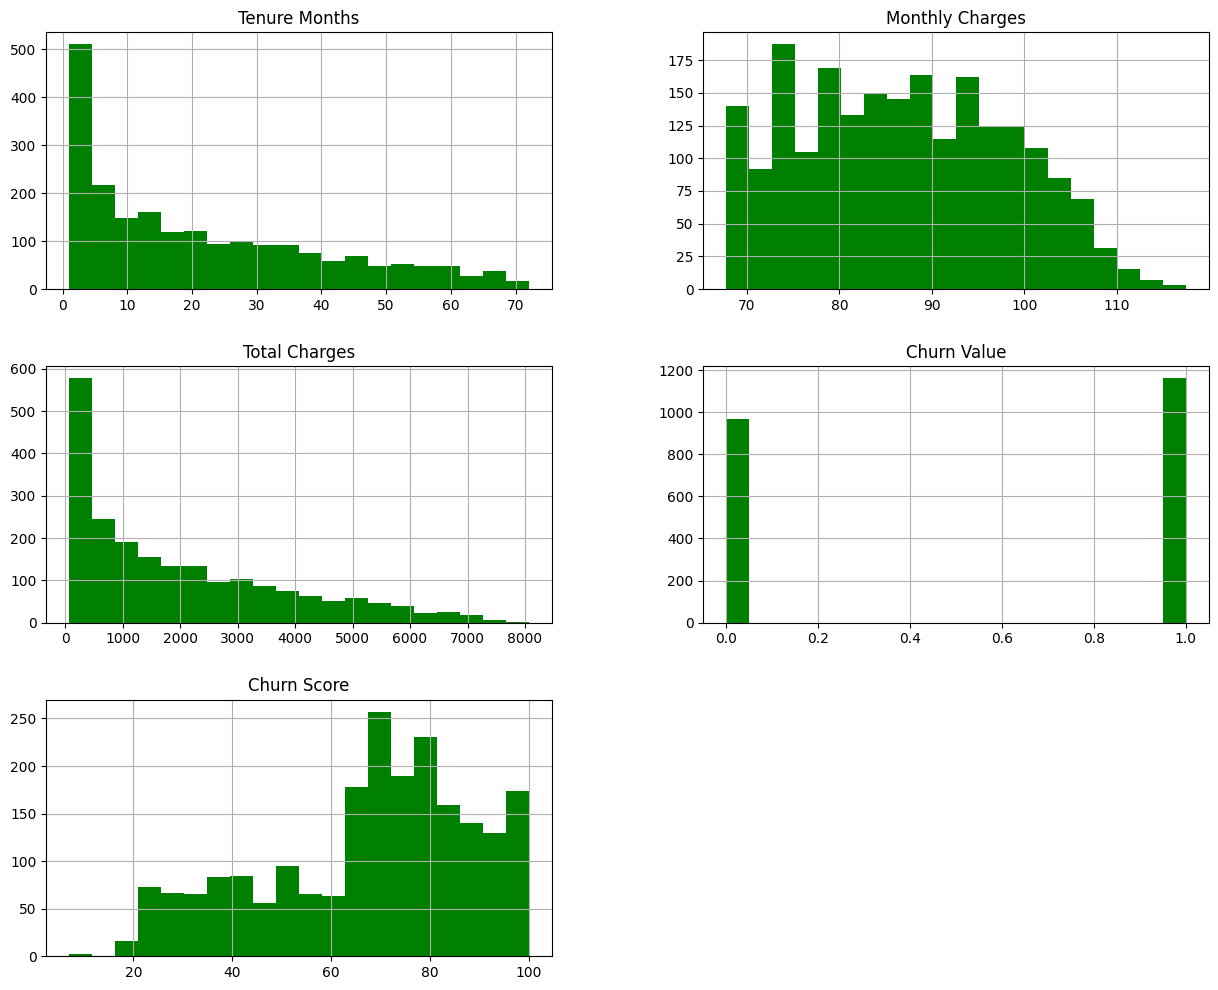

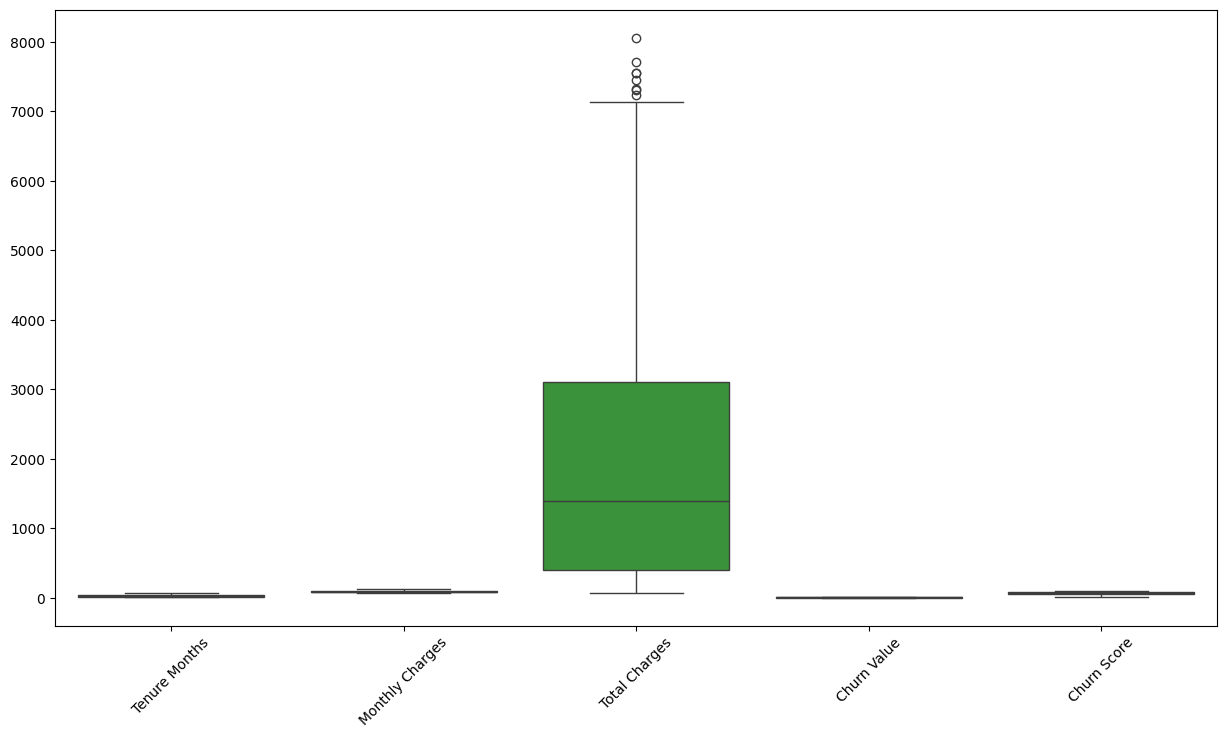

In [ ]:
numerical_df = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score']

df[numerical_df].hist(bins=20, figsize=(15,12), color='green')
plt.show()
plt.figure(figsize=(15,8))
sns.boxplot(data=df[numerical_df])
plt.xticks(rotation=45)
plt.show()

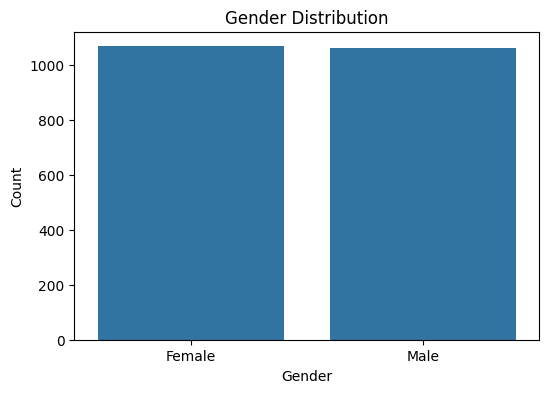

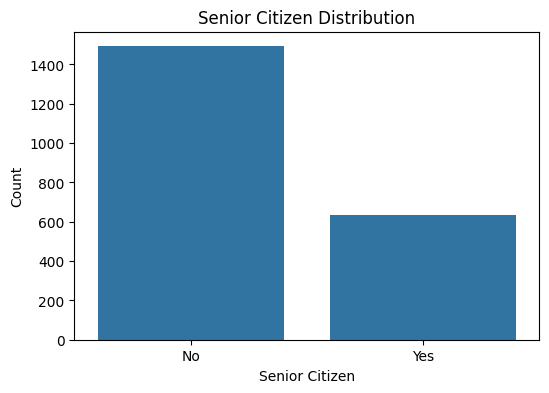

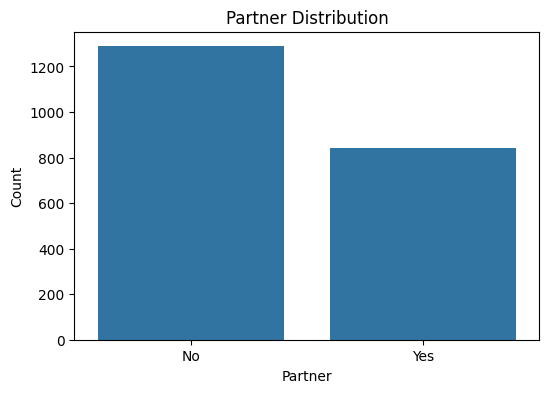

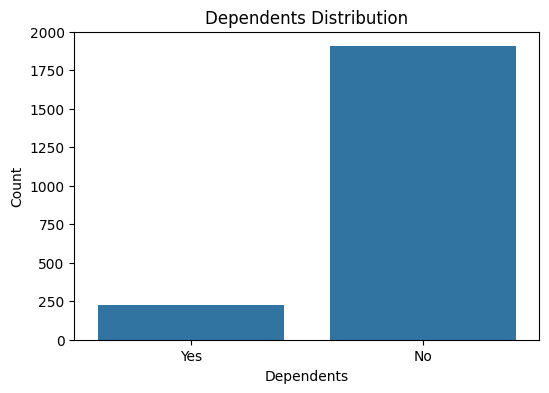

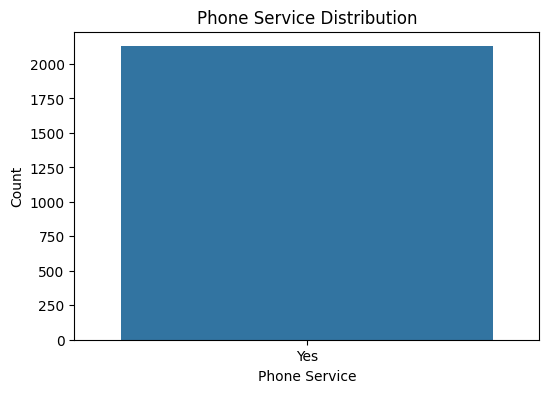

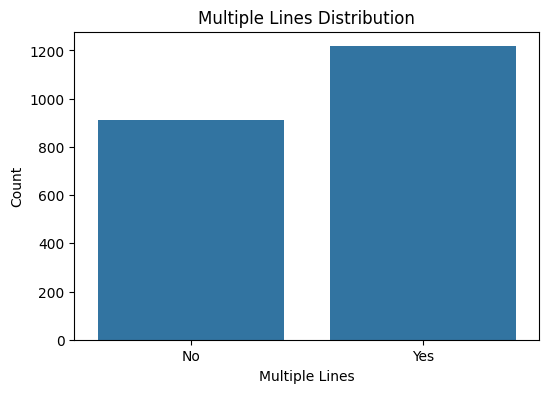

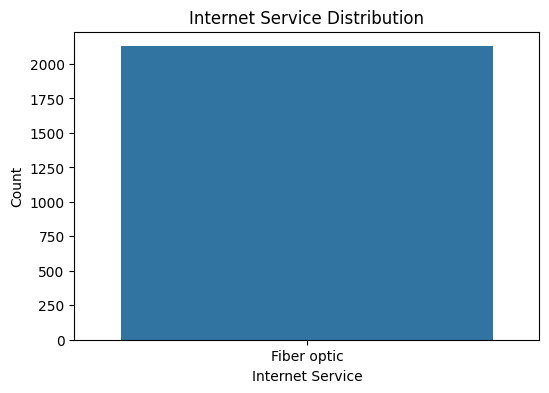

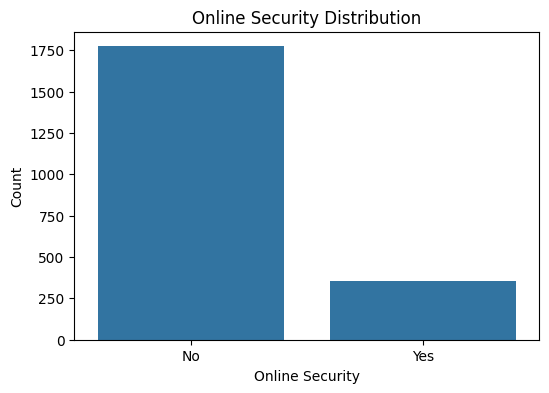

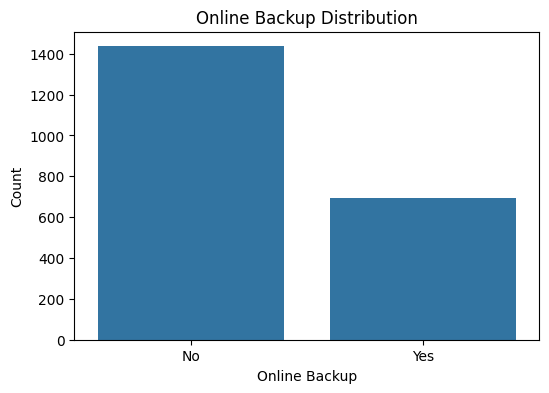

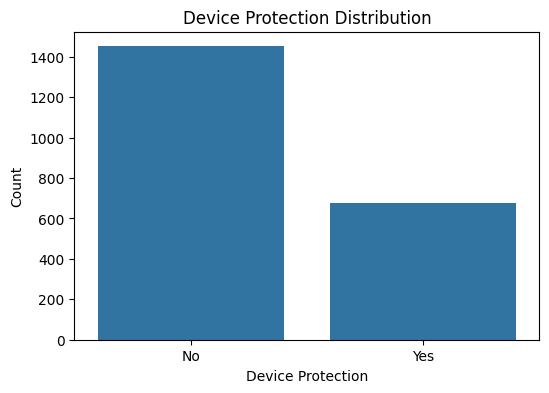

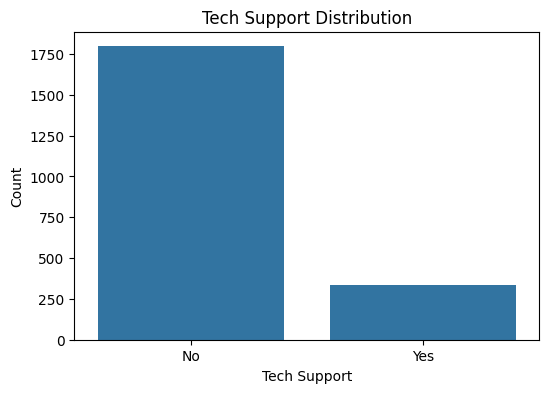

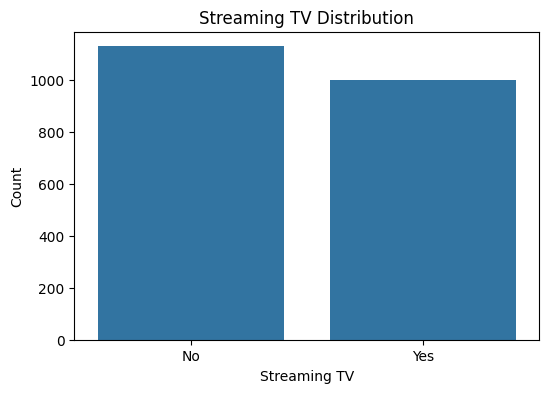

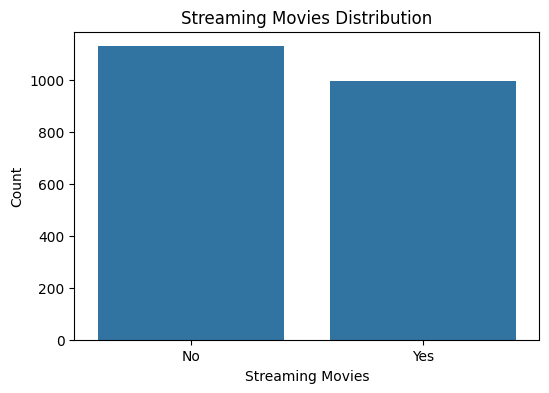

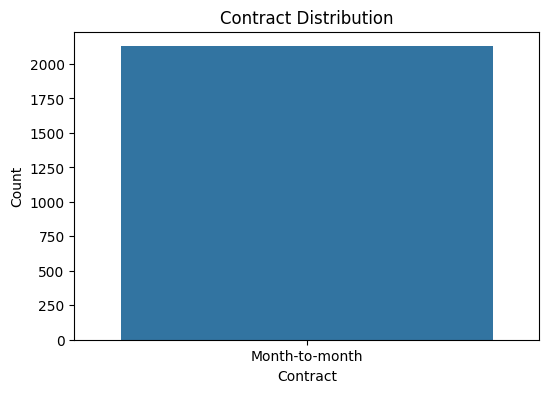

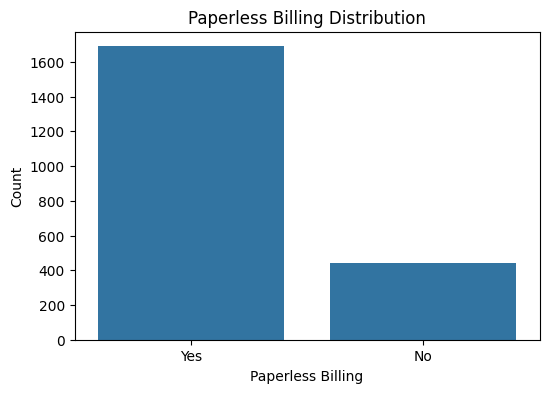

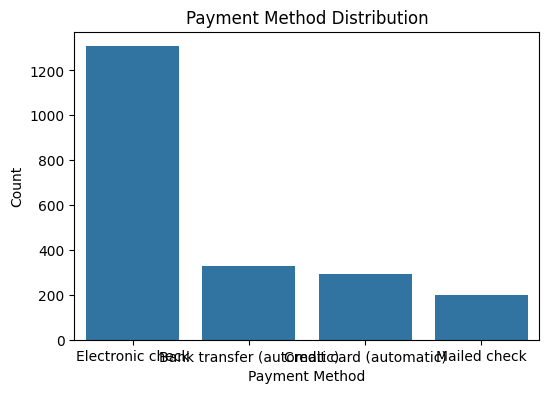

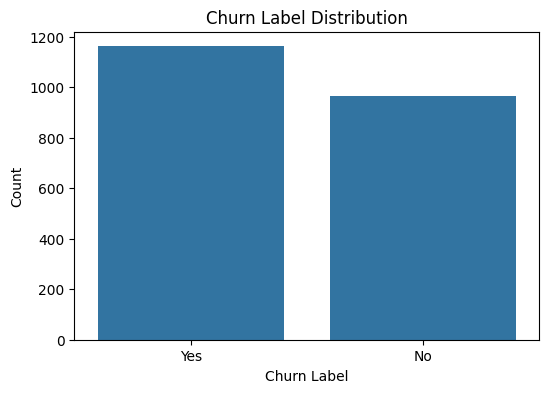

In [ ]:
cat_df = df.select_dtypes(include=["object"])
for col in cat_df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"{col} Distribution")
    plt.show()

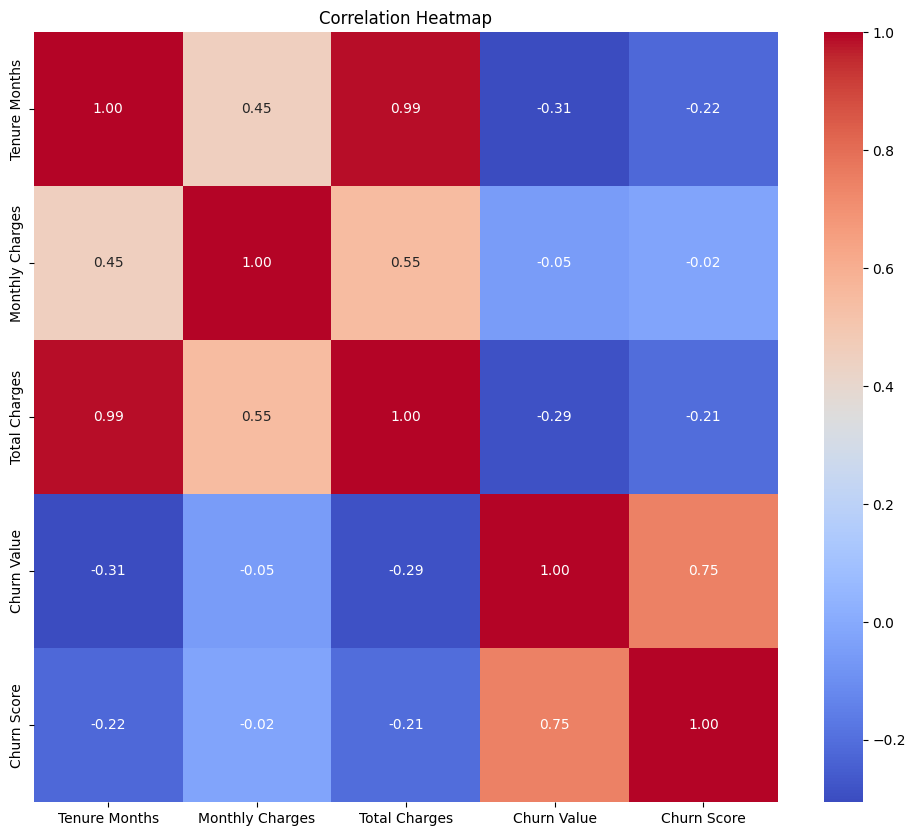

In [ ]:
plt.figure(figsize=(12,10))
corr = df[numerical_df].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

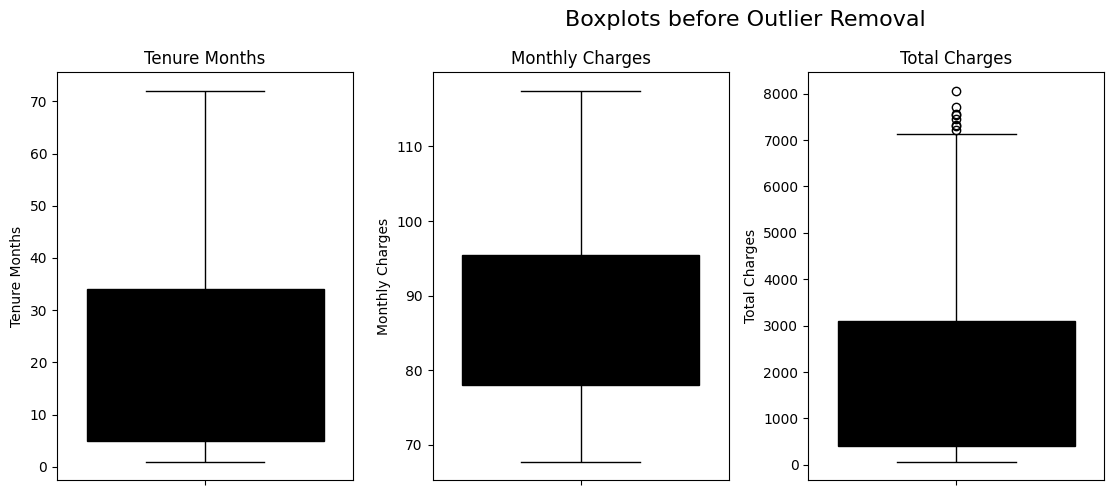

In [ ]:
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']
plt.figure(figsize=(15, 5))
plt.suptitle("Boxplots before Outlier Removal", fontsize=16)

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(data=df, y=col, color='black')
    plt.title(col)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

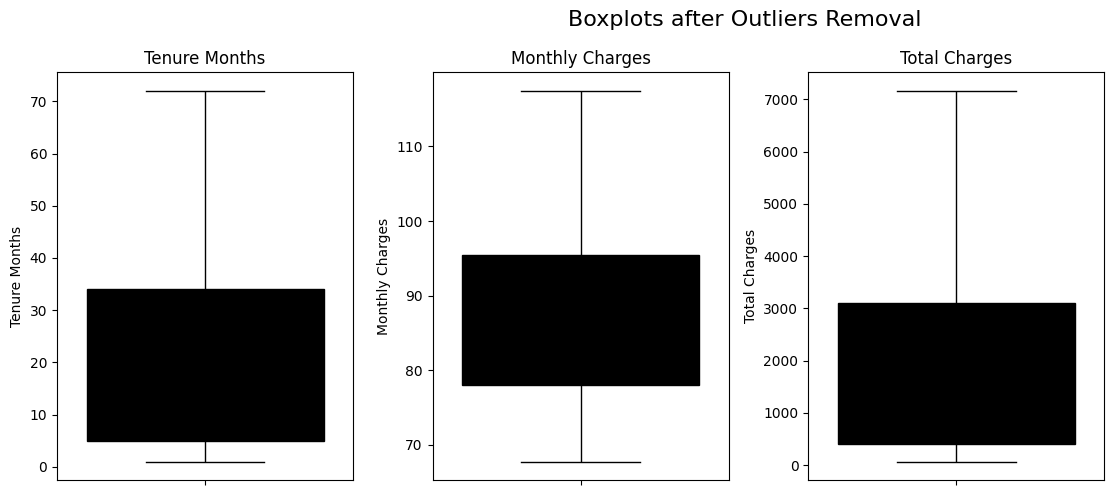

In [ ]:
plt.figure(figsize=(15, 5))
plt.suptitle("Boxplots after Outliers Removal", fontsize=16)

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(data=df, y=col, color='black')
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
cat_df.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Churn Label']

In [ ]:
skewness = df[numerical_df].skew()
skewness

,0
Tenure Months,0.789422
Monthly Charges,0.174469
Total Charges,0.954874
Churn Value,-0.185127
Churn Score,-0.589934


In [ ]:
from sklearn.preprocessing import PowerTransformer

# 1. Initialize the PowerTransformer with Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson')

# 2. Select the numerical columns that need skewness correction
cols_to_transform = ['Tenure Months', 'Total Charges']

# 3. Fit and transform the data
# (Note: PowerTransformer also scales the data to have a mean of 0 and variance of 1)
df[cols_to_transform] = pt.fit_transform(df[cols_to_transform])

# 4. Check your new skewness values
print("New skewness values after Yeo-Johnson:")
print(df[cols_to_transform].skew())


New skewness values after Yeo-Johnson:
Tenure Months   -0.106317
Total Charges   -0.135535
dtype: float64


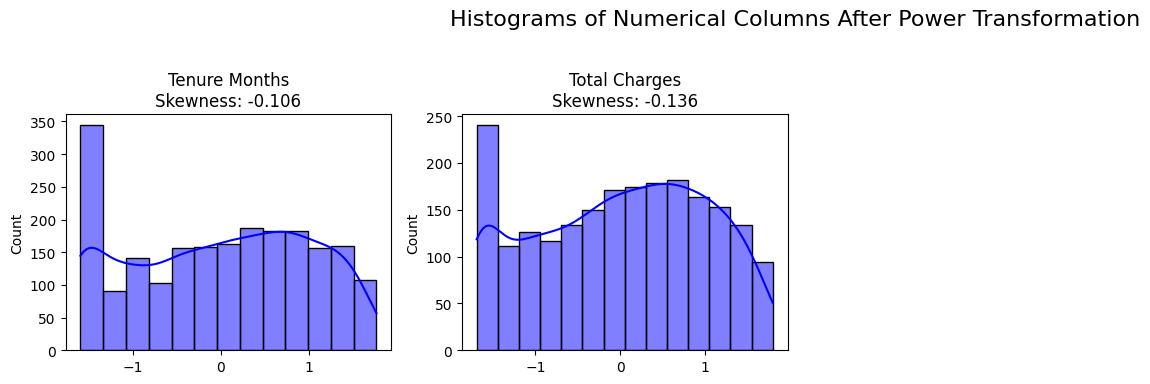

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_plots = len(cols_to_transform)
rows = (num_plots + 3) // 4

plt.figure(figsize=(16, 4 * rows))
plt.suptitle("Histograms of Numerical Columns After Power Transformation", fontsize=16)

for i, col in enumerate(cols_to_transform, 1):
    plt.subplot(rows, 4, i)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f"{col}\nSkewness: {df[col].skew():.3f}")
    plt.xlabel('')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import pandas as pd
categorical_cols = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
    'Internet Service', 'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract',
    'Paperless Billing', 'Payment Method'
]

X = df.drop(columns=['Churn Value', 'Churn Label'], errors='ignore')
y = df['Churn Value']

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

print(f"Features dataset shape: {X_encoded.shape}")
print("\n Encoded columns as a preview:")
print([col for col in X_encoded.columns if '_' in col][:])

Features dataset shape: (2128, 19)

 Encoded columns as a preview:
['Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Multiple Lines_Yes', 'Online Security_Yes', 'Online Backup_Yes', 'Device Protection_Yes', 'Tech Support_Yes', 'Streaming TV_Yes', 'Streaming Movies_Yes', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']


In [ ]:
import warnings
import pandas as pd
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import joblib

warnings.filterwarnings("ignore")

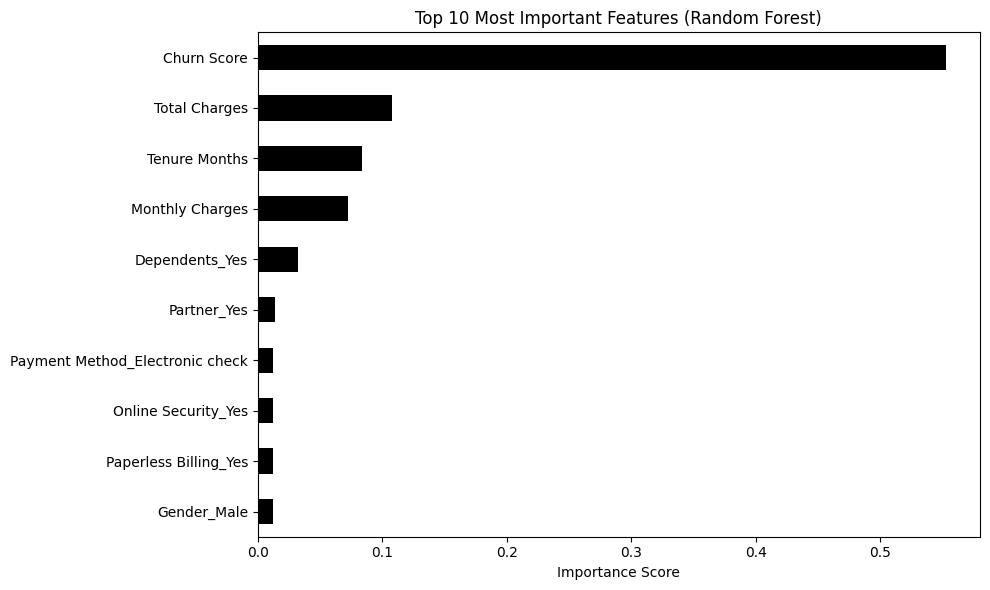

Top 10 critical features:
Churn Score                        0.552596
Total Charges                      0.107805
Tenure Months                      0.083541
Monthly Charges                    0.072466
Dependents_Yes                     0.032212
Partner_Yes                        0.013738
Payment Method_Electronic check    0.012650
Online Security_Yes                0.012371
Paperless Billing_Yes              0.012342
Gender_Male                        0.012242
dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_encoded, y)


importances = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='black').invert_yaxis()
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 10 critical features:")
print(importances.head(10))


In [ ]:
X_encoded.columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Multiple Lines_Yes', 'Online Security_Yes', 'Online Backup_Yes',
       'Device Protection_Yes', 'Tech Support_Yes', 'Streaming TV_Yes',
       'Streaming Movies_Yes', 'Paperless Billing_Yes',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

In [ ]:
features =  ['Churn Score','Total Charges','Tenure Months','Monthly Charges','Dependents_Yes','Partner_Yes','Payment Method_Electronic check','Online Security_Yes','Paperless Billing_Yes','Gender_Male']
X = X_encoded[features]
y = df['Churn Value']

In [ ]:
print (X.shape)
print (y.shape)

(2128, 10)
(2128,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.columns)
print(y_test)

Index(['Churn Score', 'Total Charges', 'Tenure Months', 'Monthly Charges',
       'Dependents_Yes', 'Partner_Yes', 'Payment Method_Electronic check',
       'Online Security_Yes', 'Paperless Billing_Yes', 'Gender_Male'],
      dtype='object')
282     1
2000    0
1706    0
988     1
2019    0
       ..
305     1
973     1
611     1
2110    0
192     1
Name: Churn Value, Length: 426, dtype: int64


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

performance_data = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    performance_data.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall (Sensitivity)': recall,
        'F1 Score': f1
    })

# 3. Display the true classification results
results_df = pd.DataFrame(performance_data)
print(results_df.to_string(index=False))


              Model  Accuracy  Precision  Recall (Sensitivity)  F1 Score
Logistic Regression  0.859155   0.861789              0.890756  0.876033
      Random Forest  0.889671   0.868726              0.945378  0.905433
      Decision Tree  0.861502   0.871369              0.882353  0.876827
                KNN  0.875587   0.854406              0.936975  0.893788
            XGBoost  0.870892   0.864542              0.911765  0.887526


In [ ]:
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
Best Score: 0.8860249977229633


In [ ]:
best_model = random_search.best_estimator_

In [ ]:
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [ ]:
print(type(best_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [ ]:
train_acc = best_model.score(X_train, y_train)
test_acc = best_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9377203290246768
Test Accuracy: 0.892018779342723


In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 87.5 MB/s eta 0:00:00
--2026-07-14 15:56:54--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.7.1/cloudflared-linux-amd64 [following]
--2026-07-14 15:56:55--  https://github.com/cloudflare/cloudflared/releases/download/2026.7.1/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/84b7d829-7d74-4679-b2dd-09368a130047?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-14T16%3A44%3A17Z&rscd=attachment%3B+filename%3D

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle

st.set_page_config(page_title="Customer Churn Predictor", layout="centered")
st.title("📊 Telecom Customer Churn Prediction")
st.write("Enter the customer details below to predict if they will leave or stay.")


@st.cache_resource
def load_model():

    with open('/content/best_model.pkl', 'rb') as file:
        return pickle.load(file)

try:
    model = load_model()
except FileNotFoundError:
    st.error("Model file 'best_model.pkl' not found. Please check the file path.")
    st.stop()

st.subheader("Customer Demographics & Account Info")
col1, col2 = st.columns(2)

with col1:
    tenure = st.number_input("Tenure (Months)", min_value=0, max_value=72, value=12)
    monthly_charges = st.number_input("Monthly Charges ($)", min_value=0.0, value=50.0)
    total_charges = st.number_input("Total Charges ($)", min_value=0.0, value=600.0)
    churn_score = st.number_input("Churn Score", min_value=0, max_value=100, value=50)

with col2:
    contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
    internet_service = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    tech_support = st.selectbox("Tech Support", ["Yes", "No", "No internet service"])


    gender_male = st.selectbox("Gender", ["Male", "Female"]) == "Male"
    partner = st.selectbox("Has Partner?", ["Yes", "No"]) == "Yes"
    dependents = st.selectbox("Has Dependents?", ["Yes", "No"]) == "Yes"
    online_security = st.selectbox("Online Security?", ["Yes", "No"]) == "Yes"
    paperless_billing = st.selectbox("Paperless Billing?", ["Yes", "No"]) == "Yes"
    payment_electronic = st.selectbox("Payment Method", ["Electronic check", "Other"]) == "Electronic check"

input_data = {
    'Churn Score': churn_score,
    'Total Charges': total_charges,
    'Tenure Months': tenure,
    'Monthly Charges': monthly_charges,
    'Dependents_Yes': 1 if dependents else 0,
    'Partner_Yes': 1 if partner else 0,
    'Payment Method_Electronic check': 1 if payment_electronic else 0,
    'Online Security_Yes': 1 if online_security else 0,
    'Paperless Billing_Yes': 1 if paperless_billing else 0,
    'Gender_Male': 1 if gender_male else 0
}

input_df = pd.DataFrame([input_data])

# 5. Prediction logic
if st.button("Predict Churn Status", type="primary"):
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1] * 100

    st.write("---")
    if prediction == 1:
        st.error(f"🚨 **High Risk!** This customer is likely to **CHURN**.")
        st.write(f"Probability of leaving: **{probability:.2f}%**")
    else:
        st.success(f"🎉 **Safe!** This customer is likely to **STAY**.")
        st.write(f"Probability of staying: **{100 - probability:.2f}%**")



Writing app.py


In [ ]:
!streamlit run /content/app.py &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://sacramento-roulette-slides-enhanced.trycloudflare.com
